# 31. Price Anomaly Detection 모델 구현

## 목적
카테고리별 통계 기반 가격 이상치 탐지 모델을 구현합니다.

## 구현 방법
1. **Modified Z-Score**: 중앙값과 MAD(Median Absolute Deviation) 기반
2. **카테고리별 통계**: 각 카테고리의 가격 분포 특성 반영
3. **이상치 심각도 스코어**: 정상(0), 경고(1), 위험(2) 레벨

## 의존성
- `data/processed/price/price_analysis_results.pkl` (30번 노트북 출력)
- `data/processed/price/price_data.pkl` (30번 노트북 출력)

In [2]:
# 필수 라이브러리 임포트
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 데이터 로드

In [3]:
# 경로 설정
INPUT_DIR = Path('../data/processed/price')

# 30번 노트북 결과 로드
analysis_path = INPUT_DIR / 'price_analysis_results.pkl'
data_path = INPUT_DIR / 'price_data.pkl'

if analysis_path.exists() and data_path.exists():
    with open(analysis_path, 'rb') as f:
        analysis_results = pickle.load(f)
    
    df = pd.read_pickle(data_path)
    
    print(f"분석 결과 로드 완료: {analysis_path}")
    print(f"가격 데이터 로드 완료: {data_path}")
    print(f"데이터 shape: {df.shape}")
    LOAD_FROM_PREVIOUS = True
else:
    print("이전 노트북 결과가 없습니다. 30번 노트북을 먼저 실행해주세요.")
    print("시뮬레이션 데이터로 진행합니다...")
    
    # 시뮬레이션 데이터 생성
    np.random.seed(42)
    n_products = 500
    
    category_params = {
        '신선식품': {'mean': 8000, 'std': 3000},
        '유제품': {'mean': 5000, 'std': 2000},
        '음료': {'mean': 3000, 'std': 1500},
        '과자/스낵': {'mean': 4000, 'std': 2000},
        '냉동식품': {'mean': 7000, 'std': 3000}
    }
    
    data = []
    for i in range(n_products):
        cat_name = np.random.choice(list(category_params.keys()))
        params = category_params[cat_name]
        
        price = np.random.normal(params['mean'], params['std'])
        price = max(100, round(price / 100) * 100)
        
        # 5% 이상치
        if np.random.random() < 0.05:
            price = price * np.random.choice([0.1, 5])
        
        data.append({
            'product_id': i + 1,
            'name': f"{cat_name} 제품 {i+1}",
            'price': price,
            'category_name': cat_name,
            'log_price': np.log10(max(1, price))
        })
    
    df = pd.DataFrame(data)
    analysis_results = {'category_bounds': {}}
    LOAD_FROM_PREVIOUS = False

df.head()

분석 결과 로드 완료: ..\data\processed\price\price_analysis_results.pkl
가격 데이터 로드 완료: ..\data\processed\price\price_data.pkl
데이터 shape: (1600, 8)


,product_id,name,price,original_price,discount_rate,category_id,category_name,log_price
0,1600,simplus 스위트 피클 슬라이스 680G,3490.0,NaN,0.0,13,라면/간편식품/통조림,3.542825
1,1599,simplus 할라피뇨 슬라이스 340G,1990.0,NaN,0.0,13,라면/간편식품/통조림,3.298853
2,1598,슬라이스드 오이피클 500G,2490.0,NaN,0.0,13,라면/간편식품/통조림,3.396199
3,1597,직수입 블랙올리브 340G,2490.0,NaN,0.0,13,라면/간편식품/통조림,3.396199
4,1596,직수입 블랙올리브 슬라이스 340G,2490.0,NaN,0.0,13,라면/간편식품/통조림,3.396199


## 2. Modified Z-Score 계산

Modified Z-Score는 이상치에 더 강건한 통계량을 사용합니다:
- 평균 대신 **중앙값(median)**
- 표준편차 대신 **MAD(Median Absolute Deviation)**

$$\text{Modified Z-Score} = \frac{0.6745 \times (x_i - \tilde{x})}{\text{MAD}}$$

여기서 0.6745는 정규분포에서 MAD와 표준편차의 관계를 맞추는 상수입니다.

In [4]:
def calculate_mad(series):
    """
    Median Absolute Deviation 계산
    MAD = median(|x_i - median(x)|)
    """
    median = series.median()
    mad = (series - median).abs().median()
    return mad


def calculate_modified_zscore(value, median, mad):
    """
    Modified Z-Score 계산
    
    Args:
        value: 개별 값
        median: 중앙값
        mad: MAD
    
    Returns:
        float: Modified Z-Score
    """
    if mad == 0:
        return 0.0
    return 0.6745 * (value - median) / mad


# 테스트
test_series = df['price'].head(100)
test_mad = calculate_mad(test_series)
test_median = test_series.median()

print(f"테스트 데이터 (상위 100개):")
print(f"  중앙값: {test_median:,.0f}원")
print(f"  MAD: {test_mad:,.0f}원")

테스트 데이터 (상위 100개):
  중앙값: 4,435원
  MAD: 1,395원


## 3. 카테고리별 통계 계산

In [5]:
def build_category_statistics(df, price_column='price', use_log=True):
    """
    카테고리별 가격 통계 계산
    
    Args:
        df: 가격 데이터프레임
        price_column: 가격 컬럼명
        use_log: 로그 변환 적용 여부
    
    Returns:
        dict: 카테고리별 통계
    """
    category_stats = {}
    
    for cat_name, group in df.groupby('category_name'):
        prices = group[price_column].dropna()
        
        if len(prices) < 3:  # 최소 3개 이상 필요
            continue
        
        # 로그 변환
        if use_log:
            log_prices = np.log10(prices.clip(lower=1))
        else:
            log_prices = prices
        
        # 기본 통계
        median = log_prices.median()
        mad = calculate_mad(log_prices)
        mean = log_prices.mean()
        std = log_prices.std()
        
        # IQR 기반 통계
        q1 = log_prices.quantile(0.25)
        q3 = log_prices.quantile(0.75)
        iqr = q3 - q1
        
        # 원본 가격 통계 (표시용)
        price_median = prices.median()
        price_mean = prices.mean()
        price_std = prices.std()
        price_min = prices.min()
        price_max = prices.max()
        
        category_stats[cat_name] = {
            # 로그 스케일 통계 (이상치 탐지용)
            'log_median': median,
            'log_mad': mad,
            'log_mean': mean,
            'log_std': std,
            'log_q1': q1,
            'log_q3': q3,
            'log_iqr': iqr,
            
            # 원본 스케일 통계 (표시용)
            'price_median': price_median,
            'price_mean': price_mean,
            'price_std': price_std,
            'price_min': price_min,
            'price_max': price_max,
            
            # 메타 정보
            'n_products': len(prices),
            'use_log': use_log
        }
    
    return category_stats


# 카테고리별 통계 계산
category_statistics = build_category_statistics(df, use_log=True)

print("=" * 60)
print("카테고리별 가격 통계")
print("=" * 60)

for cat_name, stats in category_statistics.items():
    print(f"\n{cat_name} (n={stats['n_products']}):")
    print(f"  가격 중앙값: {stats['price_median']:,.0f}원")
    print(f"  가격 평균: {stats['price_mean']:,.0f}원")
    print(f"  가격 범위: {stats['price_min']:,.0f} ~ {stats['price_max']:,.0f}원")
    print(f"  로그 MAD: {stats['log_mad']:.4f}")

카테고리별 가격 통계

견과/건과/간식 (n=159):
  가격 중앙값: 5,980원
  가격 평균: 6,404원
  가격 범위: 1,000 ~ 35,900원
  로그 MAD: 0.2229

과일 (n=94):
  가격 중앙값: 8,990원
  가격 평균: 8,699원
  가격 범위: 1,290 ~ 16,900원
  로그 MAD: 0.1093

김치/반찬/절임 (n=60):
  가격 중앙값: 5,490원
  가격 평균: 6,740원
  가격 범위: 1,590 ~ 26,900원
  로그 MAD: 0.1762

두부/콩/계란 (n=54):
  가격 중앙값: 7,240원
  가격 평균: 6,954원
  가격 범위: 1,000 ~ 13,990원
  로그 MAD: 0.1894

라면/간편식품/통조림 (n=246):
  가격 중앙값: 5,990원
  가격 평균: 6,741원
  가격 범위: 890 ~ 23,900원
  로그 MAD: 0.1998

면/가루/베이커리/제빵 (n=78):
  가격 중앙값: 4,495원
  가격 평균: 6,797원
  가격 범위: 990 ~ 49,900원
  로그 MAD: 0.1468

수산물/해산물/건어물 (n=95):
  가격 중앙값: 6,990원
  가격 평균: 7,648원
  가격 범위: 1,190 ~ 29,900원
  로그 MAD: 0.2101

쌀/잡곡 (n=60):
  가격 중앙값: 9,990원
  가격 평균: 16,843원
  가격 범위: 3,990 ~ 64,900원
  로그 MAD: 0.0760

양념/조미/소스/오일 (n=173):
  가격 중앙값: 5,890원
  가격 평균: 6,820원
  가격 범위: 980 ~ 26,500원
  로그 MAD: 0.1583

우유/유제품 (n=92):
  가격 중앙값: 5,990원
  가격 평균: 6,988원
  가격 범위: 890 ~ 18,990원
  로그 MAD: 0.1765

육류 (n=118):
  가격 중앙값: 8,790원
  가격 평균: 9,847원
  가격 범위: 950 ~ 5

## 4. 이상치 탐지 함수 구현

In [6]:
class PriceAnomalyDetector:
    """
    가격 이상치 탐지기
    
    Modified Z-Score와 IQR 방식을 조합하여 이상치를 탐지합니다.
    """
    
    # 이상치 레벨 정의
    LEVEL_NORMAL = 0    # 정상
    LEVEL_WARNING = 1   # 경고 (주의 필요)
    LEVEL_DANGER = 2    # 위험 (명확한 이상치)
    
    def __init__(self, category_stats, 
                 warning_threshold=2.5, 
                 danger_threshold=3.5,
                 use_log=True):
        """
        Args:
            category_stats: 카테고리별 통계
            warning_threshold: 경고 레벨 임계값 (Modified Z-Score)
            danger_threshold: 위험 레벨 임계값
            use_log: 로그 변환 사용 여부
        """
        self.category_stats = category_stats
        self.warning_threshold = warning_threshold
        self.danger_threshold = danger_threshold
        self.use_log = use_log
        
        # 글로벌 폴백 통계 (카테고리 정보 없을 때)
        self.global_stats = self._calculate_global_stats()
    
    def _calculate_global_stats(self):
        """전체 데이터 기반 글로벌 통계 계산"""
        if not self.category_stats:
            return None
        
        # 모든 카테고리의 중앙값들의 중앙값
        all_medians = [s['log_median'] for s in self.category_stats.values()]
        all_mads = [s['log_mad'] for s in self.category_stats.values()]
        
        return {
            'log_median': np.median(all_medians),
            'log_mad': np.median(all_mads)
        }
    
    def detect(self, price, category_name=None):
        """
        단일 가격의 이상치 여부 탐지
        
        Args:
            price: 가격
            category_name: 카테고리명 (없으면 글로벌 통계 사용)
        
        Returns:
            dict: {
                'is_anomaly': bool,
                'level': int (0, 1, 2),
                'modified_zscore': float,
                'direction': str ('high', 'low', 'normal'),
                'expected_range': tuple (min, max)
            }
        """
        # 유효성 검사
        if price is None or price <= 0:
            return {
                'is_anomaly': True,
                'level': self.LEVEL_DANGER,
                'modified_zscore': float('inf'),
                'direction': 'invalid',
                'expected_range': (0, 0),
                'message': '유효하지 않은 가격'
            }
        
        # 통계 선택
        if category_name and category_name in self.category_stats:
            stats = self.category_stats[category_name]
        elif self.global_stats:
            stats = self.global_stats
        else:
            return {
                'is_anomaly': False,
                'level': self.LEVEL_NORMAL,
                'modified_zscore': 0,
                'direction': 'unknown',
                'expected_range': (0, float('inf')),
                'message': '통계 정보 없음'
            }
        
        # 로그 변환
        if self.use_log:
            log_price = np.log10(max(1, price))
        else:
            log_price = price
        
        # Modified Z-Score 계산
        median = stats['log_median']
        mad = stats['log_mad']
        
        if mad == 0:
            mad = 0.0001  # 0으로 나누기 방지
        
        modified_zscore = 0.6745 * (log_price - median) / mad
        abs_zscore = abs(modified_zscore)
        
        # 레벨 판정
        if abs_zscore >= self.danger_threshold:
            level = self.LEVEL_DANGER
            is_anomaly = True
        elif abs_zscore >= self.warning_threshold:
            level = self.LEVEL_WARNING
            is_anomaly = True
        else:
            level = self.LEVEL_NORMAL
            is_anomaly = False
        
        # 방향 판정
        if modified_zscore > self.warning_threshold:
            direction = 'high'
        elif modified_zscore < -self.warning_threshold:
            direction = 'low'
        else:
            direction = 'normal'
        
        # 예상 정상 범위 계산
        if self.use_log:
            log_lower = median - self.warning_threshold * mad / 0.6745
            log_upper = median + self.warning_threshold * mad / 0.6745
            expected_range = (10 ** log_lower, 10 ** log_upper)
        else:
            expected_range = (
                median - self.warning_threshold * mad / 0.6745,
                median + self.warning_threshold * mad / 0.6745
            )
        
        return {
            'is_anomaly': is_anomaly,
            'level': level,
            'modified_zscore': modified_zscore,
            'direction': direction,
            'expected_range': expected_range,
            'message': self._get_message(level, direction, price, expected_range)
        }
    
    def _get_message(self, level, direction, price, expected_range):
        """이상치 메시지 생성"""
        if level == self.LEVEL_NORMAL:
            return '정상 가격 범위'
        
        level_str = '경고' if level == self.LEVEL_WARNING else '위험'
        direction_str = '높음' if direction == 'high' else '낮음'
        
        return f"[{level_str}] 가격이 비정상적으로 {direction_str} (현재: {price:,.0f}원, 예상 범위: {expected_range[0]:,.0f}~{expected_range[1]:,.0f}원)"
    
    def detect_batch(self, df, price_column='price', category_column='category_name'):
        """
        배치 이상치 탐지
        
        Args:
            df: 데이터프레임
            price_column: 가격 컬럼명
            category_column: 카테고리 컬럼명
        
        Returns:
            DataFrame: 탐지 결과가 추가된 데이터프레임
        """
        results = []
        
        for idx, row in df.iterrows():
            price = row[price_column]
            category = row.get(category_column)
            
            result = self.detect(price, category)
            results.append(result)
        
        # 결과 데이터프레임 생성
        results_df = pd.DataFrame(results)
        
        # 원본 데이터와 결합
        output_df = df.copy()
        output_df['is_anomaly'] = results_df['is_anomaly']
        output_df['anomaly_level'] = results_df['level']
        output_df['modified_zscore'] = results_df['modified_zscore']
        output_df['anomaly_direction'] = results_df['direction']
        
        return output_df


# 탐지기 생성
detector = PriceAnomalyDetector(
    category_stats=category_statistics,
    warning_threshold=2.5,
    danger_threshold=3.5,
    use_log=True
)

print("PriceAnomalyDetector 생성 완료")
print(f"  경고 임계값: {detector.warning_threshold}")
print(f"  위험 임계값: {detector.danger_threshold}")
print(f"  카테고리 수: {len(detector.category_stats)}")

PriceAnomalyDetector 생성 완료
  경고 임계값: 2.5
  위험 임계값: 3.5
  카테고리 수: 13


## 5. 이상치 탐지 테스트

In [7]:
# 단일 가격 테스트
test_cases = [
    ('신선식품', 8000),    # 정상
    ('신선식품', 50000),   # 높음
    ('신선식품', 100),     # 낮음
    ('음료', 3000),        # 정상
    ('음료', 30000),       # 높음
    (None, 5000),          # 카테고리 없음
]

print("=" * 70)
print("이상치 탐지 테스트")
print("=" * 70)

for category, price in test_cases:
    result = detector.detect(price, category)
    
    level_str = ['정상', '경고', '위험'][result['level']]
    
    print(f"\n카테고리: {category}, 가격: {price:,}원")
    print(f"  레벨: {level_str}")
    print(f"  Modified Z-Score: {result['modified_zscore']:.2f}")
    print(f"  방향: {result['direction']}")
    print(f"  메시지: {result['message']}")

이상치 탐지 테스트

카테고리: 신선식품, 가격: 8,000원
  레벨: 정상
  Modified Z-Score: 0.48
  방향: normal
  메시지: 정상 가격 범위

카테고리: 신선식품, 가격: 50,000원
  레벨: 위험
  Modified Z-Score: 3.53
  방향: high
  메시지: [위험] 가격이 비정상적으로 높음 (현재: 50,000원, 예상 범위: 1,331~26,953원)

카테고리: 신선식품, 가격: 100원
  레벨: 위험
  Modified Z-Score: -6.80
  방향: low
  메시지: [위험] 가격이 비정상적으로 낮음 (현재: 100원, 예상 범위: 1,331~26,953원)

카테고리: 음료, 가격: 3,000원
  레벨: 정상
  Modified Z-Score: -1.23
  방향: normal
  메시지: 정상 가격 범위

카테고리: 음료, 가격: 30,000원
  레벨: 정상
  Modified Z-Score: 2.11
  방향: normal
  메시지: 정상 가격 범위

카테고리: None, 가격: 5,000원
  레벨: 정상
  Modified Z-Score: -0.30
  방향: normal
  메시지: 정상 가격 범위


In [8]:
# 전체 데이터에 대해 배치 탐지
df_detected = detector.detect_batch(df)

print("=" * 50)
print("전체 데이터 이상치 탐지 결과")
print("=" * 50)

# 요약 통계
n_total = len(df_detected)
n_normal = (df_detected['anomaly_level'] == 0).sum()
n_warning = (df_detected['anomaly_level'] == 1).sum()
n_danger = (df_detected['anomaly_level'] == 2).sum()

print(f"\n총 제품 수: {n_total}")
print(f"정상: {n_normal}개 ({n_normal/n_total*100:.1f}%)")
print(f"경고: {n_warning}개 ({n_warning/n_total*100:.1f}%)")
print(f"위험: {n_danger}개 ({n_danger/n_total*100:.1f}%)")

# 방향별 분포
print(f"\n방향별 분포:")
print(df_detected['anomaly_direction'].value_counts())

전체 데이터 이상치 탐지 결과

총 제품 수: 1600
정상: 1528개 (95.5%)
경고: 47개 (2.9%)
위험: 25개 (1.6%)

방향별 분포:
anomaly_direction
normal    1528
low         43
high        29
Name: count, dtype: int64


In [9]:
# 이상치 상세 확인
anomalies = df_detected[df_detected['is_anomaly'] == True].sort_values('modified_zscore', key=abs, ascending=False)

print("\n탐지된 이상치 (상위 10개):")
print(anomalies[['name', 'price', 'category_name', 'anomaly_level', 'modified_zscore', 'anomaly_direction']].head(10).to_string())


탐지된 이상치 (상위 10개):
                          name    price category_name  anomaly_level  modified_zscore anomaly_direction
1592       슈퍼오닝 추청 20KG(포)/특등급  64900.0          쌀/잡곡              2         7.214287              high
1593       믿고먹는 농협 안심쌀 20KG(포)  63900.0          쌀/잡곡              2         7.154420              high
1594          서해안 간척지쌀 20KG(포)  60900.0          쌀/잡곡              2         6.969034              high
1597      대왕님표 여주쌀 진상미 10KG(포)  48900.0          쌀/잡곡              2         6.122965              high
1596        햇살드리 수향미 쌀 10KG(포)  43900.0          쌀/잡곡              2         5.707120              high
1599  25년산 프리미엄 고시히카리쌀 10KG(포)  42900.0          쌀/잡곡              2         5.618284              high
1211      제스프리 더큰 그린키위(뉴질랜드) 개   1290.0            과일              2        -5.204109               low
1084    한돈 일품포크 뒷다리살 100G/돼지고기    950.0            육류              2        -4.833824               low
1598   GAP 천년의 솜씨 신동진쌀 10KG(포)  34900.0      

In [10]:
# 카테고리별 이상치 분포
category_anomaly_stats = df_detected.groupby('category_name').agg({
    'is_anomaly': ['sum', 'count', 'mean']
}).round(3)

category_anomaly_stats.columns = ['n_anomalies', 'n_total', 'anomaly_rate']
category_anomaly_stats['anomaly_rate'] = (category_anomaly_stats['anomaly_rate'] * 100).round(1)
category_anomaly_stats = category_anomaly_stats.sort_values('anomaly_rate', ascending=False)

print("\n카테고리별 이상치 분포:")
print(category_anomaly_stats.to_string())


카테고리별 이상치 분포:
               n_anomalies  n_total  anomaly_rate
category_name                                    
쌀/잡곡                    17       60          28.3
육류                      18      118          15.3
두부/콩/계란                  4       54           7.4
과일                       6       94           6.4
면/가루/베이커리/제빵             5       78           6.4
채소/샐러드/버섯/나물             9      188           4.8
양념/조미/소스/오일              4      173           2.3
우유/유제품                   2       92           2.2
김치/반찬/절임                 1       60           1.7
라면/간편식품/통조림              4      246           1.6
음료                       2      183           1.1
견과/건과/간식                 0      159           0.0
수산물/해산물/건어물              0       95           0.0


## 6. 시각화

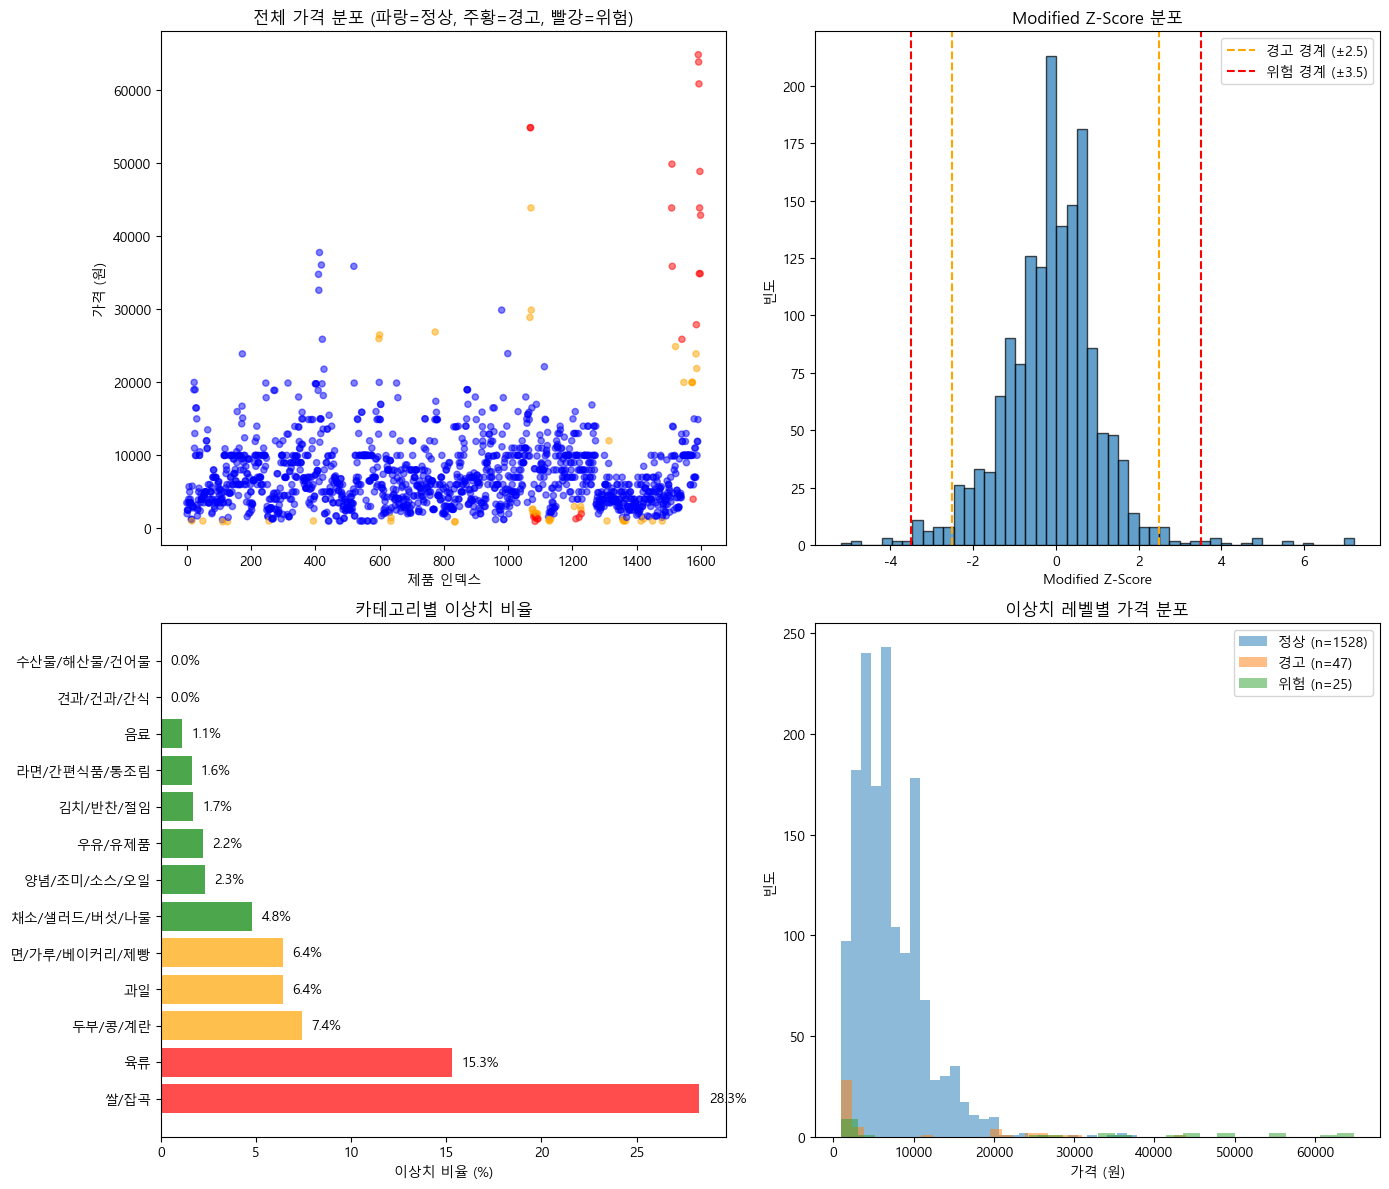

In [11]:
# 이상치 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. 전체 가격 분포와 이상치
ax1 = axes[0, 0]
colors = df_detected['anomaly_level'].map({0: 'blue', 1: 'orange', 2: 'red'})
ax1.scatter(range(len(df_detected)), df_detected['price'], c=colors, alpha=0.5, s=20)
ax1.set_xlabel('제품 인덱스')
ax1.set_ylabel('가격 (원)')
ax1.set_title('전체 가격 분포 (파랑=정상, 주황=경고, 빨강=위험)')

# 2. Modified Z-Score 분포
ax2 = axes[0, 1]
ax2.hist(df_detected['modified_zscore'], bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(-detector.warning_threshold, color='orange', linestyle='--', label=f'경고 경계 (±{detector.warning_threshold})')
ax2.axvline(detector.warning_threshold, color='orange', linestyle='--')
ax2.axvline(-detector.danger_threshold, color='red', linestyle='--', label=f'위험 경계 (±{detector.danger_threshold})')
ax2.axvline(detector.danger_threshold, color='red', linestyle='--')
ax2.set_xlabel('Modified Z-Score')
ax2.set_ylabel('빈도')
ax2.set_title('Modified Z-Score 분포')
ax2.legend()

# 3. 카테고리별 이상치 비율
ax3 = axes[1, 0]
categories = category_anomaly_stats.index.tolist()
rates = category_anomaly_stats['anomaly_rate'].values
colors_bar = ['red' if r > 10 else 'orange' if r > 5 else 'green' for r in rates]
bars = ax3.barh(categories, rates, color=colors_bar, alpha=0.7)
ax3.set_xlabel('이상치 비율 (%)')
ax3.set_title('카테고리별 이상치 비율')
for bar, rate in zip(bars, rates):
    ax3.text(rate + 0.5, bar.get_y() + bar.get_height()/2, f'{rate:.1f}%', va='center')

# 4. 이상치 레벨별 가격 분포
ax4 = axes[1, 1]
level_labels = ['정상', '경고', '위험']
for level in [0, 1, 2]:
    subset = df_detected[df_detected['anomaly_level'] == level]['price']
    if len(subset) > 0:
        ax4.hist(subset, bins=30, alpha=0.5, label=f'{level_labels[level]} (n={len(subset)})')
ax4.set_xlabel('가격 (원)')
ax4.set_ylabel('빈도')
ax4.set_title('이상치 레벨별 가격 분포')
ax4.legend()

plt.tight_layout()
plt.show()

## 7. 모델 성능 평가

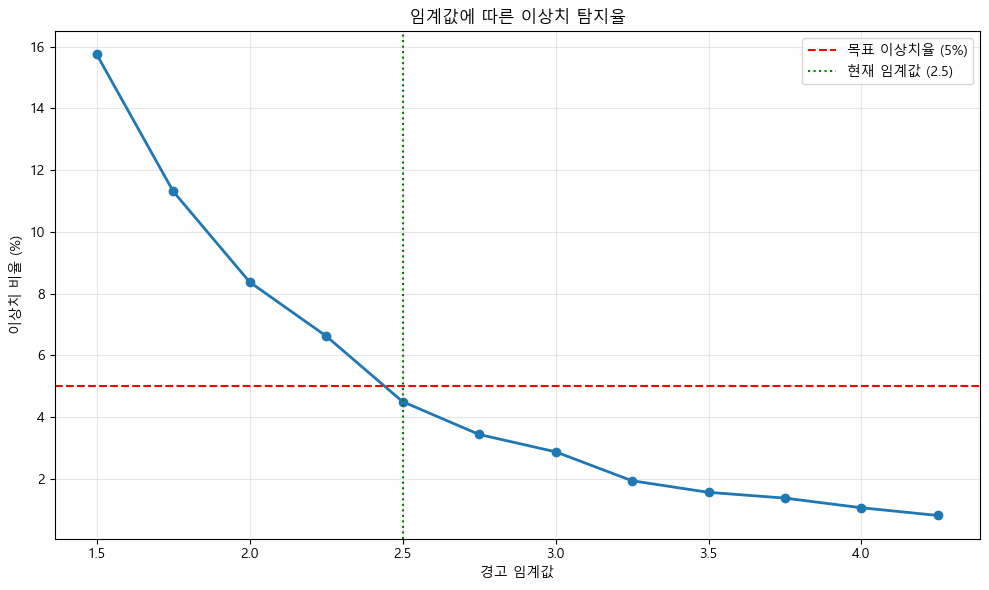


목표 이상치율(5.0%)에 가장 가까운 임계값: 2.5
해당 임계값의 이상치율: 4.50%


In [12]:
# 임계값 민감도 분석
thresholds = np.arange(1.5, 4.5, 0.25)
anomaly_rates = []

for thresh in thresholds:
    temp_detector = PriceAnomalyDetector(
        category_stats=category_statistics,
        warning_threshold=thresh,
        danger_threshold=thresh + 1,
        use_log=True
    )
    temp_results = temp_detector.detect_batch(df)
    rate = temp_results['is_anomaly'].mean() * 100
    anomaly_rates.append(rate)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, anomaly_rates, marker='o', linewidth=2)
ax.axhline(y=5, color='red', linestyle='--', label='목표 이상치율 (5%)')
ax.axvline(x=detector.warning_threshold, color='green', linestyle=':', label=f'현재 임계값 ({detector.warning_threshold})')
ax.set_xlabel('경고 임계값')
ax.set_ylabel('이상치 비율 (%)')
ax.set_title('임계값에 따른 이상치 탐지율')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최적 임계값 찾기 (5% 이상치율 목표)
target_rate = 5.0
optimal_idx = np.argmin(np.abs(np.array(anomaly_rates) - target_rate))
optimal_threshold = thresholds[optimal_idx]

print(f"\n목표 이상치율({target_rate}%)에 가장 가까운 임계값: {optimal_threshold}")
print(f"해당 임계값의 이상치율: {anomaly_rates[optimal_idx]:.2f}%")

## 8. 탐지 결과 저장

In [13]:
# 탐지 결과 저장
OUTPUT_DIR = Path('../data/processed/price')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 탐지기 상태 저장
detector_state = {
    'version': '1.0.0',
    'created_at': datetime.now(),
    'category_stats': category_statistics,
    'warning_threshold': detector.warning_threshold,
    'danger_threshold': detector.danger_threshold,
    'use_log': detector.use_log,
    'global_stats': detector.global_stats
}

detector_path = OUTPUT_DIR / 'price_anomaly_detector.pkl'
with open(detector_path, 'wb') as f:
    pickle.dump(detector_state, f)

print(f"탐지기 상태 저장 완료: {detector_path}")

# 탐지 결과 저장
results_path = OUTPUT_DIR / 'anomaly_detection_results.pkl'
df_detected.to_pickle(results_path)

print(f"탐지 결과 저장 완료: {results_path}")

탐지기 상태 저장 완료: ..\data\processed\price\price_anomaly_detector.pkl
탐지 결과 저장 완료: ..\data\processed\price\anomaly_detection_results.pkl


## 9. 요약

In [14]:
print("=" * 60)
print("Price Anomaly Detection 모델 구현 완료")
print("=" * 60)

print(f"\n🎯 모델 설정:")
print(f"   방법: Modified Z-Score (카테고리별 + 로그 변환)")
print(f"   경고 임계값: {detector.warning_threshold}")
print(f"   위험 임계값: {detector.danger_threshold}")

print(f"\n📊 탐지 결과:")
print(f"   총 제품: {n_total}개")
print(f"   정상: {n_normal}개 ({n_normal/n_total*100:.1f}%)")
print(f"   경고: {n_warning}개 ({n_warning/n_total*100:.1f}%)")
print(f"   위험: {n_danger}개 ({n_danger/n_total*100:.1f}%)")

print(f"\n📁 저장된 파일:")
print(f"   탐지기 상태: {detector_path}")
print(f"   탐지 결과: {results_path}")

print("\n" + "=" * 60)

Price Anomaly Detection 모델 구현 완료

🎯 모델 설정:
   방법: Modified Z-Score (카테고리별 + 로그 변환)
   경고 임계값: 2.5
   위험 임계값: 3.5

📊 탐지 결과:
   총 제품: 1600개
   정상: 1528개 (95.5%)
   경고: 47개 (2.9%)
   위험: 25개 (1.6%)

📁 저장된 파일:
   탐지기 상태: ..\data\processed\price\price_anomaly_detector.pkl
   탐지 결과: ..\data\processed\price\anomaly_detection_results.pkl



## 검증 체크리스트

### 필수 확인 항목
- [ ] 카테고리별 통계 계산 완료
- [ ] PriceAnomalyDetector 클래스 구현 완료
- [ ] 단일/배치 탐지 기능 테스트 완료
- [ ] 임계값 민감도 분석 완료
- [ ] 탐지기 상태 저장 완료

### 다음 단계
32번 노트북에서 최종 Pickle 파일을 생성합니다.